<a href="https://colab.research.google.com/github/sara-sgit/Plant-Disease-Classification/blob/main/Feature_Selection_2_RFE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This script mounts Google Drive for file access in Colab,
# and imports essential libraries for data processing and machine learning:
# - NumPy for numerical operations,
# - StandardScaler for feature normalization,
# - pickle for saving/loading serialized Python objects,
# - os for handling file system operations.

from google.colab import drive
drive.mount('/content/drive')
import numpy as np
from sklearn.preprocessing import StandardScaler
import pickle as pk
import os

Mounted at /content/drive


In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

import features

In [ ]:
# Load the training feature sets from pickled files for three different models (DenseNet, ResNet, and VGG) with Leaky ReLU activation:
# - The DenseNet feature set for training is loaded into 'x_tr1'.
# - The ResNet feature set for training is loaded into 'x_tr2'.
# - The VGG feature set for training is loaded into 'x_tr3'.

with open('/content/drive/MyDrive/BENNANI_AKRIB/FEATURES/DenseNet/Leaky relu/ train_densenet_80_leakyrelu.pickle', 'rb') as f:
     x_tr1= pk.load(f)


with open('/content/drive/MyDrive/BENNANI_AKRIB/FEATURES/Resnet/Leaky relu/ F_train_RESNET_Leakyrelu.pickle', 'rb') as f:
     x_tr2= pk.load(f)

with open('/content/drive/MyDrive/BENNANI_AKRIB/FEATURES/vgg/LEAKY RELU/ right_features_training_LEAKYREL.pickle', 'rb') as f:
     x_tr3= pk.load(f)



#_______________________________________________________________________________________________________________



with open('/content/drive/MyDrive/BENNANI_AKRIB/FEATURES/DenseNet/Leaky relu/test_densenet_80_leakyrelu.pickle', 'rb') as f:
     x_ts1= pk.load(f)
with open('/content/drive/MyDrive/BENNANI_AKRIB/FEATURES/Resnet/Leaky relu/F_test_RESNET_leakyrelu.pickle', 'rb') as f:
     x_ts2= pk.load(f)
with open('/content/drive/MyDrive/BENNANI_AKRIB/FEATURES/vgg/LEAKY RELU/ right_features_test_LEAKYREL.pickle', 'rb') as f:
     x_ts3= pk.load(f)

with open('/content/drive/MyDrive/BENNANI_AKRIB/FEATURES/labels/Y_train.pickle', 'rb') as f:
     y_tr= pk.load(f)


with open('/content/drive/MyDrive/BENNANI_AKRIB/FEATURES/labels/Y_test.pickle', 'rb') as f:
     y_ts= pk.load(f)

In [ ]:
# Concatenate the training deep features from the three models (DenseNet, ResNet, and VGG) along the feature axis (axis=1):
# This combines the feature vectors for each sample from the three different models into a single extended feature vector for training.
x_tr= np.concatenate((x_tr1 ,x_tr2,x_tr3),axis=1)


# Concatenate the testing deep features from the three models (DenseNet, ResNet, and VGG) along the feature axis (axis=1):
# This combines the feature vectors for each sample from the three different models into a single extended feature vector for testing.
x_ts= np.concatenate((x_ts1 ,x_ts2,x_ts3),axis=1)

In [ ]:
# Import the necessary libraries for Recursive Feature Elimination (RFE):
# - output from google.colab for handling Colab outputs (e.g., displaying results in Colab notebooks)
# - SVC (Support Vector Classifier) for training the model during feature selection
# - load_digits to load a sample dataset of digits for feature selection
# - RFE (Recursive Feature Elimination) for performing feature selection by recursively removing features and selecting the best ones
# - matplotlib.pyplot for visualizing the results of feature selection
from google.colab import output
from sklearn.svm import SVC
from sklearn.datasets import load_digits
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt


In [ ]:
# Initialize the StandardScaler to normalize the feature values:
# - Scales the features so they have a mean of 0 and a standard deviation of 1, improving the performance of the SVC.
scD = StandardScaler()

# Apply feature scaling to the DenseNet training and test features:
# - X_trainD: The training features 'x_tr1' are scaled using fit_transform().
# - X_testD: The test features 'x_ts1' are transformed using transform() to ensure consistency with the training data scaling.
X_trainD = scD.fit_transform(x_tr1)
X_testD = scD.transform(x_ts1)

# Initialize the Support Vector Classifier (SVC) with a linear kernel and regularization parameter C = 1:
# - The SVC will be used as the estimator within RFE to evaluate feature importance.
svc = SVC(kernel="linear", C=1)

# Create the RFE object for Recursive Feature Elimination:
# - This will recursively eliminate features based on their importance as determined by the SVC estimator.
# - n_features_to_select=300 specifies we want to retain the top 300 features.
# - step=100 defines the number of features to remove in each iteration of RFE.
# - verbose=1 prints the process of the elimination to track progress.
rfeD = RFE(estimator=svc, n_features_to_select=300, step=100, verbose=1)

# Fit the RFE object to the training data (X_trainD) and corresponding labels (y_tr):
# - This will perform the RFE procedure and select the top 300 most important features for classification.
rfeD.fit(X_trainD, y_tr)

# Transform the training and test datasets to include only the selected features:
# - X_train_pD: The transformed training data with only the selected features.
# - X_test_pD: The transformed test data with only the selected features.
X_train_pD = rfeD.transform(X_trainD)
X_test_pD = rfeD.transform(X_testD)

# Play a completion sound in the Colab environment after RFE process is finished:
# - Using JavaScript to play a sound for notification when the RFE fitting is done.
output.eval_js('new Audio("https://ssl.gstatic.com/dictionary/static/sounds/20180430/complete--_us_1.mp3").play()')


In [ ]:
# Create a pipeline with a StandardScaler and Support Vector Classifier (SVC) using a Radial Basis Function (RBF) kernel:
# - The StandardScaler scales the features, ensuring they have a mean of 0 and a standard deviation of 1 before fitting the SVC.
# - The SVC uses the RBF kernel, a popular choice for non-linear classification tasks. C=1 is the regularization parameter, and gamma='scale' adjusts the kernel’s sensitivity to the data.
svm = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1, gamma='scale'))

# Fit the SVM model to the training data, using float32 for compatibility with GPU-based training:
# - X_train_pD: The training features after feature selection (from RFE).
# - y_tr: The corresponding labels for the training data.
# - .astype(np.float32): Ensures that the training data is in float32 format, which can be more efficient on GPUs.
svm.fit(X_train_pD.astype(np.float32), y_tr.astype(np.float32))

# Predict the labels of the test data:
# - X_test_pD: The test features after feature selection.
# - The prediction is performed using the trained SVM model.
y_pred = svm.predict(X_test_pD.astype(np.float32))

# __________________________________#########   Confusion Matrix   #############_____________________________________________________

# Import necessary metrics for evaluating the classification results:
from sklearn.metrics import classification_report, confusion_matrix

# Print the confusion matrix to evaluate the classification performance:
# - This matrix compares the true labels (y_ts) with the predicted labels (y_pred) to show how many instances were correctly classified versus misclassified.
print('confusion matrix')
print(confusion_matrix(y_ts, y_pred))

# Calculate the classification accuracy using the formula:
# - The expression (labels==y_pred)*1 creates a binary array where 1 means the prediction was correct and 0 means incorrect.
# - sum(...) counts the number of correct predictions.
# - Dividing by the total number of predictions (len(y_pred)) gives the accuracy as a proportion of correct predictions.
labels = y_ts
accuracy = sum((labels == y_pred) * 1) / len(y_pred)
print(f'Accuracy: {accuracy}')


confusion matrix
[[418   2   2   0   2   0   0   1   0   0]
 [  3 166  14   1   6   3   6   0   1   0]
 [  0   9 368   2   0   0   3   0   0   0]
 [  0   3   0 182   1   2   2   0   0   0]
 [  1   3   2   0 346   1   1   0   0   0]
 [  0   0   0   0   0 327   6   0   0   0]
 [  0   1   1   1   2  14 262   0   0   0]
 [  0   0   0   0   0   1   0 641   0   0]
 [  0   0   0   0   0   0   0   0  75   0]
 [  0   0   0   0   0   1   4   0   0 313]]


0.968125

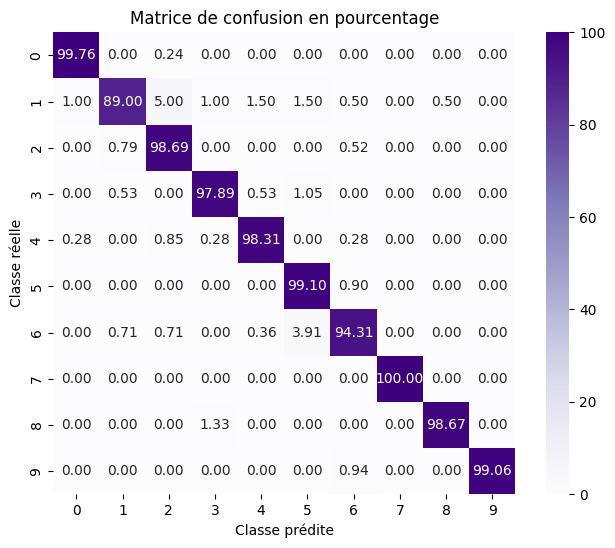

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix



# Calcul de la matrice de confusion
conf_matrix = confusion_matrix(y_ts, y_pred)

# Calcul des pourcentages dans la matrice de confusion
conf_matrix_percentage = conf_matrix / np.sum(conf_matrix, axis=1, keepdims=True) * 100

# Création de l'étiquette des classes
labels = np.unique(y_ts)
labels = [str(label) for label in labels]

# Affichage de la matrice de confusion avec des pourcentages sans le signe "%"
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_percentage, annot=True, fmt='.2f', cmap='Purples', cbar=True, square=True,
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Classe prédite')
plt.ylabel('Classe réelle')
plt.title('Matrice de confusion en pourcentage')
plt.show()

In [ ]:
#caractéristique séléctioné

selected_features = X_train[:, rfe.get_support()]


# Print the selected features
print(selected_features)
print("the shape of the selected features ",selected_features.shape)